In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [13]:
train_data = pd.read_csv("train_steel.csv")
test_data = pd.read_csv("test_steel.csv")

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)


Train shape: (19219, 35)
Test shape: (12814, 28)


In [14]:
target_cols = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
feature_cols = [col for col in train_data.columns if col not in (['id'] + target_cols)]


In [15]:

X = train_data[feature_cols]
y = train_data[target_cols]
X = pd.columns["id"].drop(X, axis=1)]

SyntaxError: unmatched ']' (1121788586.py, line 3)

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(test_data[feature_cols])



In [7]:
predictions = pd.DataFrame()
predictions["id"] = test_data["id"]



In [8]:
model = RandomForestClassifier(n_estimators=100, random_state=42)


In [9]:
for col in target_cols:
    print(f"\nTraining model for: {col}")
    model.fit(X_scaled, y[col])
    preds = model.predict_proba(X_test_scaled)[:, 1]  # probability of defect
    predictions[col] = preds



Training model for: Pastry

Training model for: Z_Scratch

Training model for: K_Scatch

Training model for: Stains

Training model for: Dirtiness

Training model for: Bumps

Training model for: Other_Faults



Training model for: Pastry


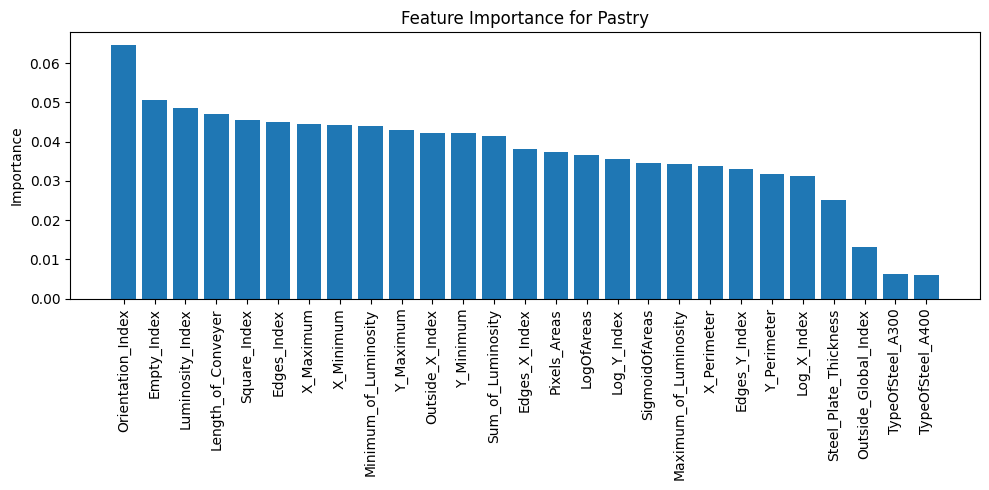


Training model for: Z_Scratch


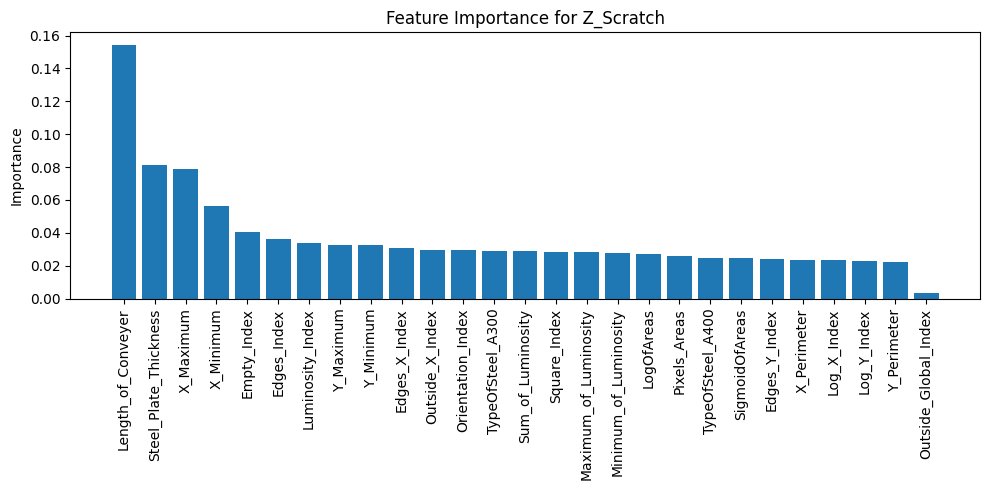


Training model for: K_Scatch


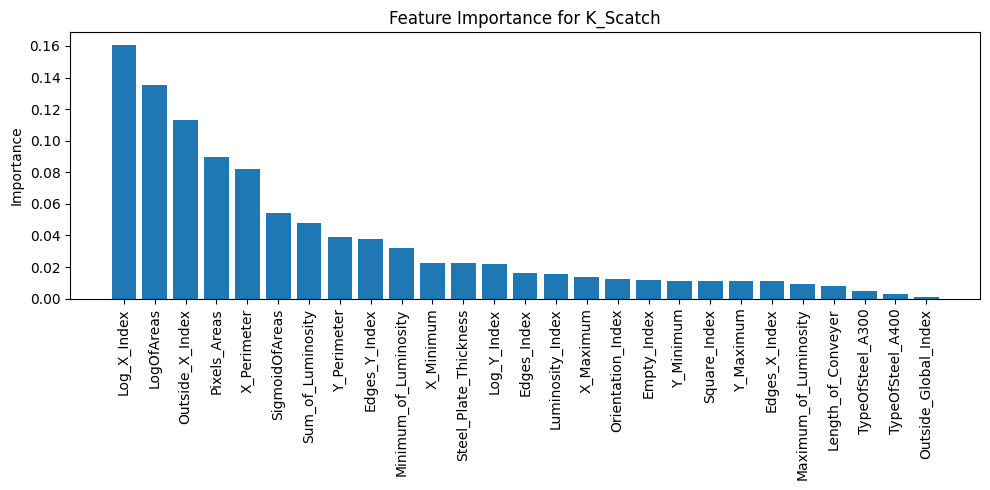


Training model for: Stains


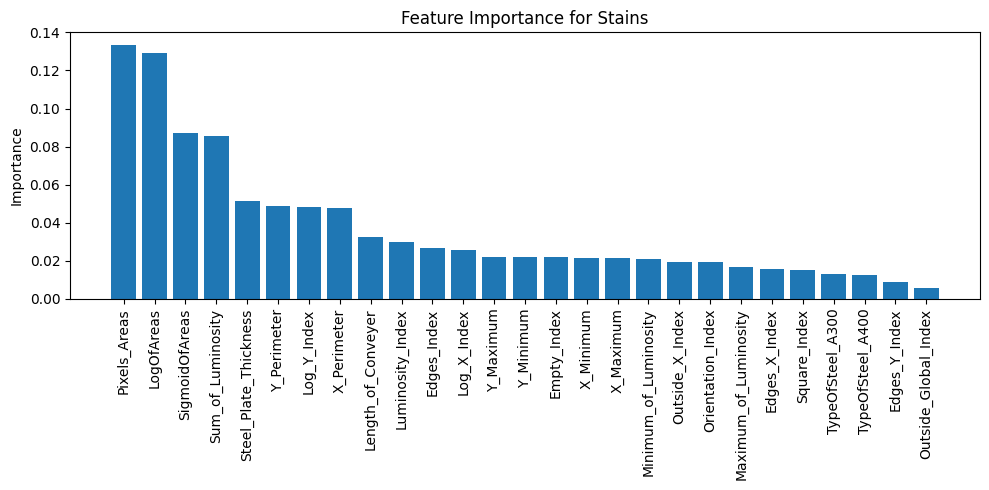


Training model for: Dirtiness


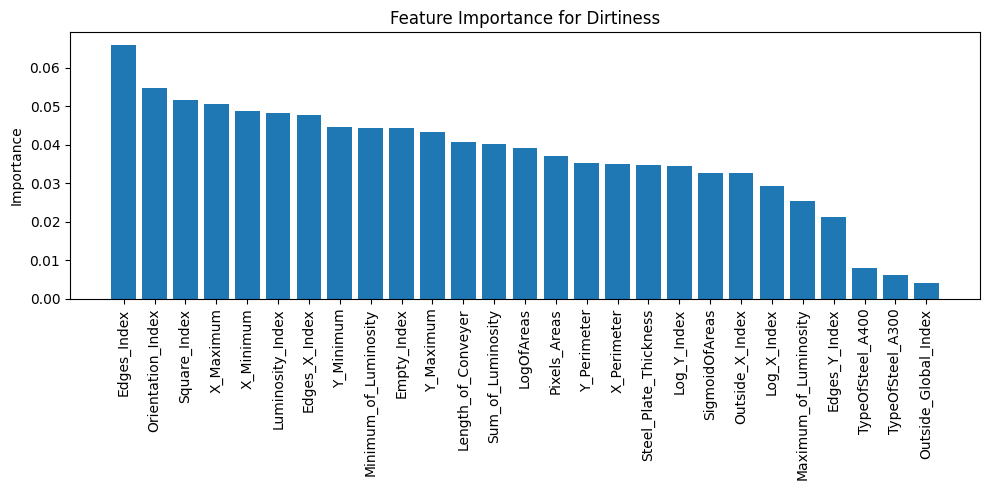


Training model for: Bumps


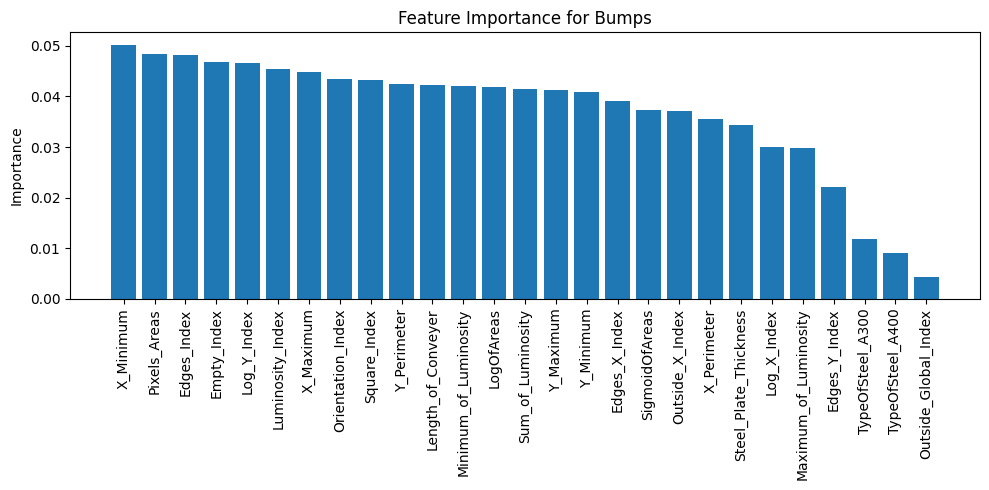


Training model for: Other_Faults


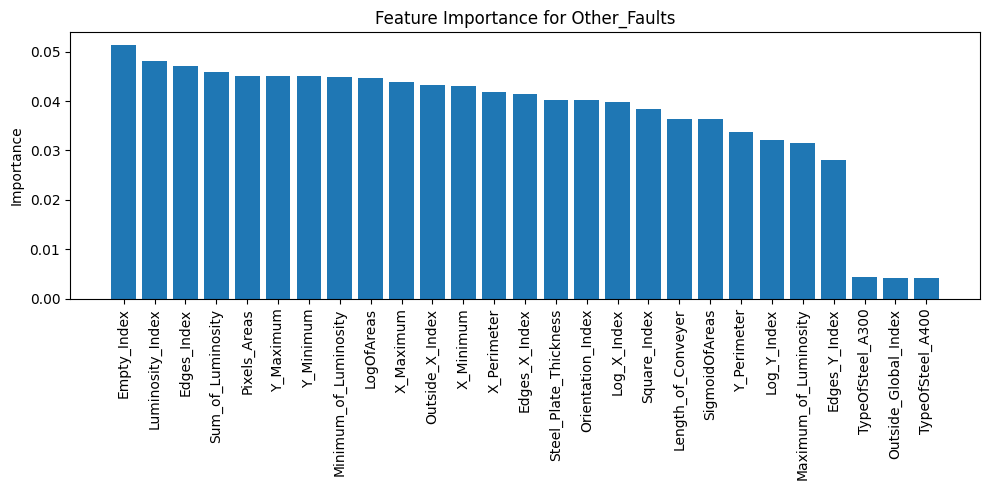

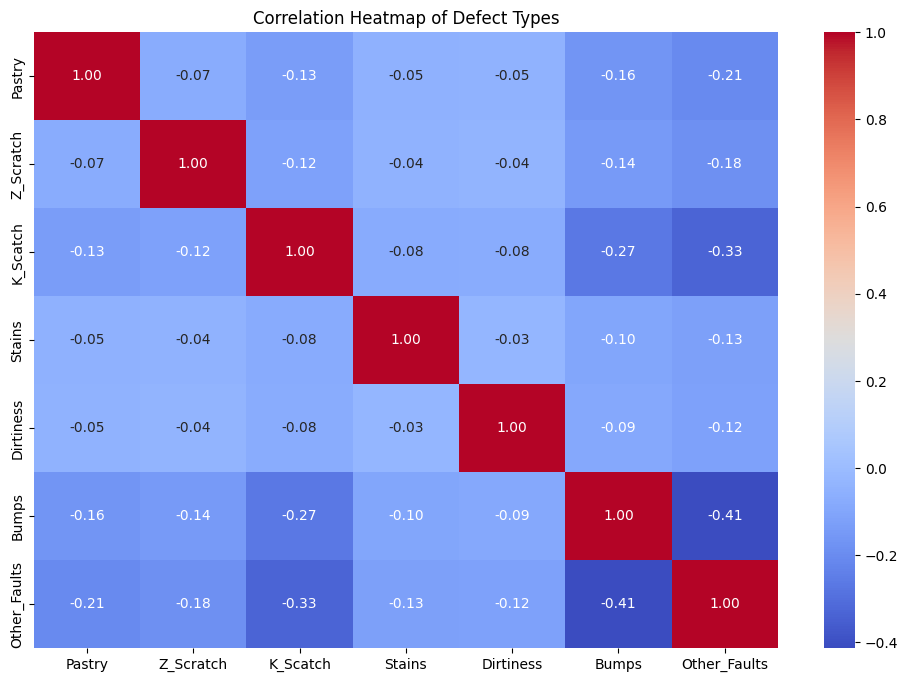

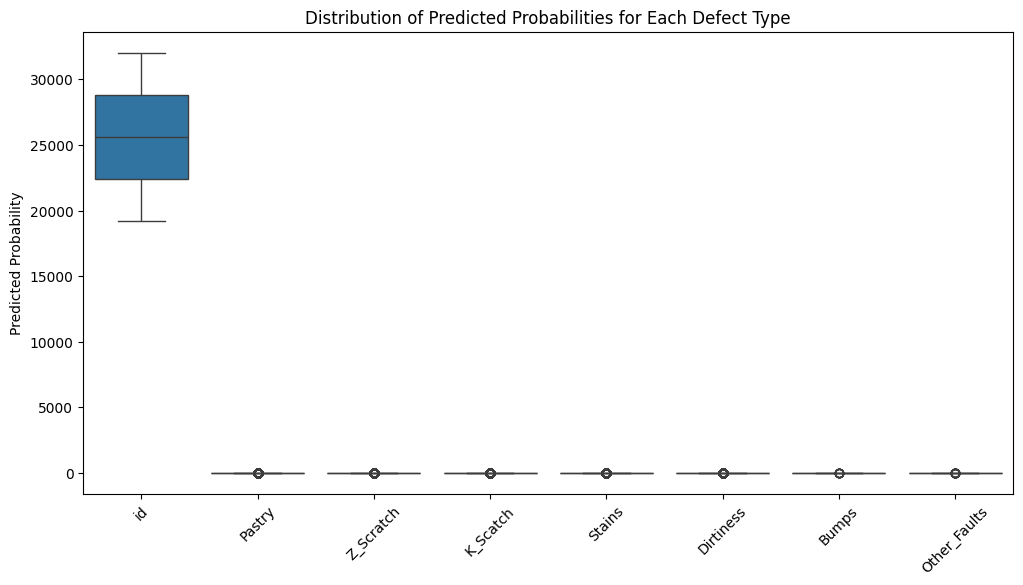

In [16]:
for col in target_cols:
    print(f"\nTraining model for: {col}")
    model.fit(X_scaled, y[col])
    preds = model.predict_proba(X_test_scaled)[:, 1]
    predictions[col] = preds

    # Plot Feature Importance
    importances = model.feature_importances_
    indices = importances.argsort()[::-1]

    plt.figure(figsize=(10, 5))
    plt.title(f"Feature Importance for {col}")
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), [feature_cols[i] for i in indices], rotation=90)
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()

# --- Correlation Heatmap for Training Data ---
plt.figure(figsize=(12, 8))
sns.heatmap(train_data[target_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Defect Types")
plt.show()

# --- Plot Predicted Probabilities for Test Data ---
pred_df = pd.DataFrame(predictions)
plt.figure(figsize=(12, 6))
sns.boxplot(data=pred_df)
plt.title("Distribution of Predicted Probabilities for Each Defect Type")
plt.ylabel("Predicted Probability")
plt.xticks(rotation=45)
plt.show()




In [ ]:
predictions.to_csv("submission_steel.csv", index=False)
print("\n✅ Submission file 'submission.csv' created successfully!")
print(predictions.head())


Retraining model on the entire training dataset...
Training and predicting for: Pastry
Training and predicting for: Z_Scratch
Training and predicting for: K_Scatch
Training and predicting for: Stains
Training and predicting for: Dirtiness
Training and predicting for: Bumps
Training and predicting for: Other_Faults
\n✅ Final submission file created successfully!


https://www.kaggle.com/competitions/playground-series-s4e3/leaderboard